In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Set random seed for reproducibility
np.random.seed(42)

# Define sample size
n = 5000

print("Creating mock dataset for cigarette smoking and lung cancer study...")
print(f"Sample size: {n} participants")

Creating mock dataset for cigarette smoking and lung cancer study...
Sample size: 5000 participants


In [2]:
# Generate demographic variables
age = np.random.normal(55, 15, n).astype(int)
age = np.clip(age, 18, 90)  # Age range 18-90

# Gender (0=Female, 1=Male)
gender = np.random.binomial(1, 0.5, n)

# Socioeconomic status (1=Low, 2=Medium, 3=High)
ses = np.random.choice([1, 2, 3], n, p=[0.3, 0.5, 0.2])

# Education level (1=Less than HS, 2=HS, 3=Some College, 4=College+)
education = np.random.choice([1, 2, 3, 4], n, p=[0.15, 0.30, 0.35, 0.20])

# Occupational exposure to carcinogens (0=No, 1=Yes)
occupational_exposure = np.random.binomial(1, 0.15, n)

# Family history of cancer (0=No, 1=Yes)
family_history = np.random.binomial(1, 0.25, n)

print("Demographic variables generated")

Demographic variables generated


In [3]:
# Generate smoking behavior with realistic correlations
# Smoking is influenced by age, gender, SES, and education

# Base smoking probability
base_smoking_prob = 0.25

# Adjust probability based on covariates
smoking_prob = base_smoking_prob
smoking_prob += 0.1 * (age > 40)  # Higher smoking in older adults
smoking_prob += 0.05 * gender  # Slightly higher in males
smoking_prob -= 0.08 * (ses == 3)  # Lower in high SES
smoking_prob -= 0.1 * (education == 4)  # Lower in college educated
smoking_prob += 0.05 * occupational_exposure  # Higher in exposed occupations

# Ensure probabilities are valid
smoking_prob = np.clip(smoking_prob, 0.05, 0.8)

# Generate smoking status (0=Never, 1=Former, 2=Current)
smoking_status = np.zeros(n, dtype=int)

# Current smokers
current_smoker = np.random.binomial(1, smoking_prob, n)
smoking_status[current_smoker == 1] = 2

# Among non-current smokers, determine former vs never
former_prob = 0.3 * (1 - smoking_prob)  # 30% of non-current are former
former_smoker = np.random.binomial(1, former_prob, n)
smoking_status[(current_smoker == 0) & (former_smoker == 1)] = 1

# Generate pack-years for current and former smokers
pack_years = np.zeros(n)
smokers_mask = smoking_status > 0
pack_years[smokers_mask] = np.random.gamma(shape=2, scale=10, size=smokers_mask.sum())
pack_years = np.clip(pack_years, 1, 100)

# Years since quitting for former smokers
years_since_quit = np.zeros(n)
former_mask = smoking_status == 1
years_since_quit[former_mask] = np.random.exponential(scale=10, size=former_mask.sum())
years_since_quit = np.clip(years_since_quit, 1, 40)

print("Smoking variables generated")
print(f"Current smokers: {np.mean(smoking_status == 2):.2%}")
print(f"Former smokers: {np.mean(smoking_status == 1):.2%}")
print(f"Never smokers: {np.mean(smoking_status == 0):.2%}")

Smoking variables generated
Current smokers: 32.64%
Former smokers: 13.48%
Never smokers: 53.88%


In [4]:
# Generate lung cancer outcome with realistic risk factors
# Base lung cancer probability increases with age and smoking

# Age effect on lung cancer risk
age_effect = 0.0001 * (age - 18) ** 1.5

# Smoking effect (dose-response relationship)
smoking_effect = np.zeros(n)
current_mask = smoking_status == 2
former_mask = smoking_status == 1

# Current smokers: risk increases with pack-years
smoking_effect[current_mask] = 0.01 * (1 + pack_years[current_mask] / 20)

# Former smokers: reduced risk but still elevated
smoking_effect[former_mask] = 0.005 * (1 + pack_years[former_mask] / 30) * np.exp(-years_since_quit[former_mask] / 20)

# Other risk factors
occupational_effect = 0.003 * occupational_exposure
family_history_effect = 0.002 * family_history
gender_effect = 0.001 * gender  # Slightly higher in males

# Combined risk
base_risk = 0.002  # Base risk for non-smokers
total_risk = base_risk + age_effect + smoking_effect + occupational_effect + family_history_effect + gender_effect

# Ensure reasonable risk bounds
total_risk = np.clip(total_risk, 0.001, 0.15)

# Generate lung cancer outcome
lung_cancer = np.random.binomial(1, total_risk, n)

print("Lung cancer outcome generated")
print(f"Overall lung cancer rate: {np.mean(lung_cancer):.2%}")
print(f"Lung cancer rate by smoking status:")
print(f"  Never smokers: {np.mean(lung_cancer[smoking_status == 0]):.2%}")
print(f"  Former smokers: {np.mean(lung_cancer[smoking_status == 1]):.2%}")
print(f"  Current smokers: {np.mean(lung_cancer[smoking_status == 2]):.2%}")

Lung cancer outcome generated
Overall lung cancer rate: 3.24%
Lung cancer rate by smoking status:
  Never smokers: 2.90%
  Former smokers: 2.82%
  Current smokers: 3.98%


In [5]:
# Generate additional health variables
# BMI (body mass index)
bmi = np.random.normal(27, 5, n)
bmi = np.clip(bmi, 15, 50)

# Physical activity (0=Sedentary, 1=Light, 2=Moderate, 3=Vigorous)
physical_activity = np.random.choice([0, 1, 2, 3], n, p=[0.25, 0.35, 0.25, 0.15])

# Alcohol consumption (0=None, 1=Light, 2=Moderate, 3=Heavy)
alcohol_consumption = np.random.choice([0, 1, 2, 3], n, p=[0.20, 0.40, 0.30, 0.10])

# Comorbidities (COPD, heart disease, etc.)
comorbidity_count = np.random.poisson(0.5, n)
comorbidity_count = np.clip(comorbidity_count, 0, 5)

# Healthcare access (0=Poor, 1=Fair, 2=Good, 3=Excellent)
healthcare_access = np.random.choice([0, 1, 2, 3], n, p=[0.15, 0.25, 0.40, 0.20])

print("Additional health variables generated")

Additional health variables generated


In [6]:
# Create the final dataset
data = pd.DataFrame({
    'participant_id': range(1, n + 1),
    'age': age,
    'gender': gender,
    'ses': ses,
    'education': education,
    'occupational_exposure': occupational_exposure,
    'family_history': family_history,
    'smoking_status': smoking_status,
    'pack_years': pack_years,
    'years_since_quit': years_since_quit,
    'lung_cancer': lung_cancer,
    'bmi': bmi,
    'physical_activity': physical_activity,
    'alcohol_consumption': alcohol_consumption,
    'comorbidity_count': comorbidity_count,
    'healthcare_access': healthcare_access
})

# Add categorical labels for better interpretability
data['gender_label'] = data['gender'].map({0: 'Female', 1: 'Male'})
data['ses_label'] = data['ses'].map({1: 'Low', 2: 'Medium', 3: 'High'})
data['education_label'] = data['education'].map({1: 'Less than HS', 2: 'HS', 3: 'Some College', 4: 'College+'})
data['smoking_status_label'] = data['smoking_status'].map({0: 'Never', 1: 'Former', 2: 'Current'})

print("Dataset created successfully!")
print(f"Shape: {data.shape}")
print("\nFirst few rows:")
print(data.head())

Dataset created successfully!
Shape: (5000, 20)

First few rows:
   participant_id  age  gender  ses  education  occupational_exposure  \
0               1   62       0    2          2                      0   
1               2   52       0    1          2                      0   
2               3   64       0    3          3                      0   
3               4   77       0    2          2                      0   
4               5   51       0    2          1                      0   

   family_history  smoking_status  pack_years  years_since_quit  lung_cancer  \
0               1               0    1.000000               1.0            0   
1               0               0    1.000000               1.0            0   
2               0               2   11.061459               1.0            0   
3               1               0    1.000000               1.0            1   
4               0               2   28.487973               1.0            0   

         bmi  p

In [7]:
# Let's examine the correlations and relationships in our dataset
print("=== DATASET SUMMARY ===")
print(f"Total participants: {len(data)}")
print(f"Lung cancer cases: {data['lung_cancer'].sum()} ({data['lung_cancer'].mean():.2%})")
print()

print("=== SMOKING DISTRIBUTION ===")
smoking_dist = data['smoking_status_label'].value_counts()
for status, count in smoking_dist.items():
    print(f"{status}: {count} ({count/len(data):.2%})")
print()

print("=== AGE DISTRIBUTION BY SMOKING STATUS ===")
for status in ['Never', 'Former', 'Current']:
    subset = data[data['smoking_status_label'] == status]
    print(f"{status}: Mean age = {subset['age'].mean():.1f} (SD = {subset['age'].std():.1f})")
print()

print("=== LUNG CANCER RATE BY SMOKING STATUS ===")
for status in ['Never', 'Former', 'Current']:
    subset = data[data['smoking_status_label'] == status]
    cancer_rate = subset['lung_cancer'].mean()
    print(f"{status}: {cancer_rate:.2%}")
print()

print("=== CORRELATION MATRIX (KEY VARIABLES) ===")
key_vars = ['age', 'smoking_status', 'pack_years', 'lung_cancer', 'occupational_exposure', 'family_history']
corr_matrix = data[key_vars].corr()
print(corr_matrix.round(3))

=== DATASET SUMMARY ===
Total participants: 5000
Lung cancer cases: 162 (3.24%)

=== SMOKING DISTRIBUTION ===
Never: 2694 (53.88%)
Current: 1632 (32.64%)
Former: 674 (13.48%)

=== AGE DISTRIBUTION BY SMOKING STATUS ===
Never: Mean age = 54.2 (SD = 14.7)
Former: Mean age = 53.2 (SD = 15.6)
Current: Mean age = 55.8 (SD = 14.2)

=== LUNG CANCER RATE BY SMOKING STATUS ===
Never: 2.90%
Former: 2.82%
Current: 3.98%

=== CORRELATION MATRIX (KEY VARIABLES) ===
                         age  smoking_status  pack_years  lung_cancer  \
age                    1.000           0.047       0.035        0.047   
smoking_status         0.047           1.000       0.652        0.027   
pack_years             0.035           0.652       1.000        0.038   
lung_cancer            0.047           0.027       0.038        1.000   
occupational_exposure  0.004           0.011      -0.009       -0.014   
family_history        -0.001           0.014       0.007       -0.019   

                       occupati

In [8]:
# Create a comprehensive data dictionary
data_dictionary = pd.DataFrame({
    'Variable': [
        'participant_id', 'age', 'gender', 'ses', 'education',
        'occupational_exposure', 'family_history', 'smoking_status',
        'pack_years', 'years_since_quit', 'lung_cancer', 'bmi',
        'physical_activity', 'alcohol_consumption', 'comorbidity_count',
        'healthcare_access'
    ],
    'Type': [
        'Integer', 'Integer', 'Binary', 'Categorical', 'Categorical',
        'Binary', 'Binary', 'Categorical', 'Continuous', 'Continuous',
        'Binary', 'Continuous', 'Categorical', 'Categorical', 'Integer',
        'Categorical'
    ],
    'Description': [
        'Unique participant identifier',
        'Age in years (18-90)',
        'Biological sex (0=Female, 1=Male)',
        'Socioeconomic status (1=Low, 2=Medium, 3=High)',
        'Education level (1=Less than HS, 2=HS, 3=Some College, 4=College+)',
        'Occupational exposure to carcinogens (0=No, 1=Yes)',
        'Family history of cancer (0=No, 1=Yes)',
        'Smoking status (0=Never, 1=Former, 2=Current)',
        'Lifetime smoking exposure in pack-years',
        'Years since quitting smoking (for former smokers)',
        'Lung cancer diagnosis (0=No, 1=Yes)',
        'Body mass index',
        'Physical activity level (0=Sedentary, 1=Light, 2=Moderate, 3=Vigorous)',
        'Alcohol consumption (0=None, 1=Light, 2=Moderate, 3=Heavy)',
        'Number of comorbid conditions',
        'Healthcare access quality (0=Poor, 1=Fair, 2=Good, 3=Excellent)'
    ],
    'Range/Values': [
        '1-5000', '18-90', '0,1', '1,2,3', '1,2,3,4',
        '0,1', '0,1', '0,1,2', '1-100', '1-40',
        '0,1', '15-50', '0,1,2,3', '0,1,2,3', '0-5',
        '0,1,2,3'
    ],
    'Notes': [
        'Sequential identifier',
        'Normally distributed around 55 years',
        'Balanced distribution',
        'Weighted toward middle SES',
        'Weighted toward higher education',
        '15% have occupational exposure',
        '25% have family history',
        'Generated with realistic correlations',
        'Only for current/former smokers',
        'Only for former smokers',
        'Primary outcome variable',
        'Normally distributed',
        'Weighted toward lower activity levels',
        'Weighted toward lighter consumption',
        'Poisson distribution',
        'Weighted toward better access'
    ]
})

print("=== DATA DICTIONARY ===")
print(data_dictionary.to_string(index=False))

=== DATA DICTIONARY ===
             Variable        Type                                                            Description Range/Values                                 Notes
       participant_id     Integer                                          Unique participant identifier       1-5000                 Sequential identifier
                  age     Integer                                                   Age in years (18-90)        18-90  Normally distributed around 55 years
               gender      Binary                                      Biological sex (0=Female, 1=Male)          0,1                 Balanced distribution
                  ses Categorical                         Socioeconomic status (1=Low, 2=Medium, 3=High)        1,2,3            Weighted toward middle SES
            education Categorical     Education level (1=Less than HS, 2=HS, 3=Some College, 4=College+)      1,2,3,4      Weighted toward higher education
occupational_exposure      Binary       

In [9]:
# Save dataset and data dictionary to the project directory
dataset_path = '/Users/vishal/Projects/opencausol/packages/opencode/cigarette_lung_cancer_dataset.csv'
dictionary_path = '/Users/vishal/Projects/opencausol/packages/opencode/cigarette_lung_cancer_data_dictionary.csv'

data.to_csv(dataset_path, index=False)
data_dictionary.to_csv(dictionary_path, index=False)

print(f"Dataset saved to: {dataset_path}")
print(f"Data dictionary saved to: {dictionary_path}")
print()

# Verify files were saved correctly
import os
print(f"Dataset file size: {os.path.getsize(dataset_path):,} bytes")
print(f"Dictionary file size: {os.path.getsize(dictionary_path):,} bytes")

Dataset saved to: /Users/vishal/Projects/opencausol/packages/opencode/cigarette_lung_cancer_dataset.csv
Data dictionary saved to: /Users/vishal/Projects/opencausol/packages/opencode/cigarette_lung_cancer_data_dictionary.csv

Dataset file size: 461,829 bytes
Dictionary file size: 1,708 bytes


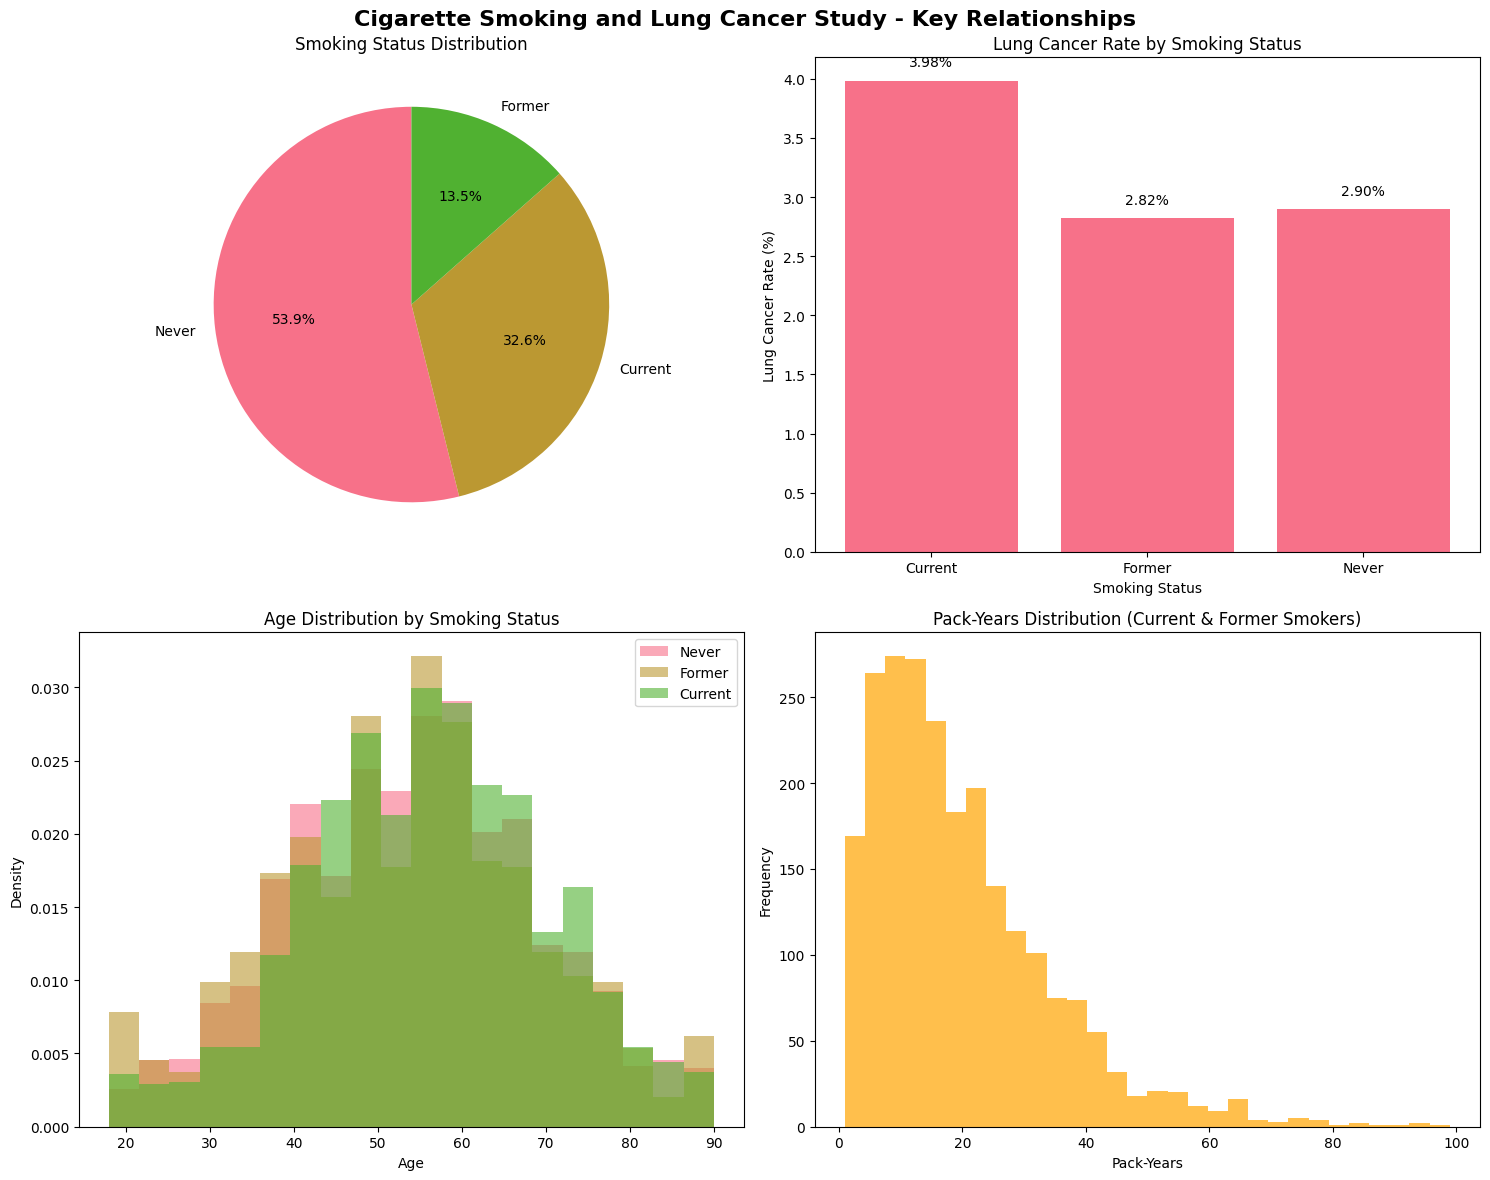

Visualization saved to: cigarette_lung_cancer_analysis.png


In [10]:
# Create some basic visualization to show the relationships
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the plotting style
plt.style.use('default')
sns.set_palette("husl")

# Create a figure with multiple subplots
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Cigarette Smoking and Lung Cancer Study - Key Relationships', fontsize=16, fontweight='bold')

# 1. Smoking status distribution
ax1 = axes[0, 0]
smoking_counts = data['smoking_status_label'].value_counts()
ax1.pie(smoking_counts.values, labels=smoking_counts.index, autopct='%1.1f%%', startangle=90)
ax1.set_title('Smoking Status Distribution')

# 2. Lung cancer rate by smoking status
ax2 = axes[0, 1]
cancer_by_smoking = data.groupby('smoking_status_label')['lung_cancer'].mean() * 100
bars = ax2.bar(cancer_by_smoking.index, cancer_by_smoking.values)
ax2.set_title('Lung Cancer Rate by Smoking Status')
ax2.set_ylabel('Lung Cancer Rate (%)')
ax2.set_xlabel('Smoking Status')

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%', ha='center', va='bottom')

# 3. Age distribution by smoking status
ax3 = axes[1, 0]
for status in ['Never', 'Former', 'Current']:
    subset = data[data['smoking_status_label'] == status]
    ax3.hist(subset['age'], alpha=0.6, label=status, bins=20, density=True)
ax3.set_title('Age Distribution by Smoking Status')
ax3.set_xlabel('Age')
ax3.set_ylabel('Density')
ax3.legend()

# 4. Pack-years distribution for smokers
ax4 = axes[1, 1]
smokers = data[data['smoking_status'] > 0]
ax4.hist(smokers['pack_years'], bins=30, alpha=0.7, color='orange')
ax4.set_title('Pack-Years Distribution (Current & Former Smokers)')
ax4.set_xlabel('Pack-Years')
ax4.set_ylabel('Frequency')

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/cigarette_lung_cancer_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.show()

print("Visualization saved to: cigarette_lung_cancer_analysis.png")

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Load the dataset
df = pd.read_csv('/Users/vishal/Projects/opencausol/packages/opencode/cigarette_lung_cancer_dataset.csv')

# Basic dataset info
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())
print("\nFirst few rows:")
print(df.head())

Dataset Shape: (5000, 20)

Column Names:
['participant_id', 'age', 'gender', 'ses', 'education', 'occupational_exposure', 'family_history', 'smoking_status', 'pack_years', 'years_since_quit', 'lung_cancer', 'bmi', 'physical_activity', 'alcohol_consumption', 'comorbidity_count', 'healthcare_access', 'gender_label', 'ses_label', 'education_label', 'smoking_status_label']

First few rows:
   participant_id  age  gender  ses  education  occupational_exposure  \
0               1   62       0    2          2                      0   
1               2   52       0    1          2                      0   
2               3   64       0    3          3                      0   
3               4   77       0    2          2                      0   
4               5   51       0    2          1                      0   

   family_history  smoking_status  pack_years  years_since_quit  lung_cancer  \
0               1               0    1.000000               1.0            0   
1           

In [12]:
# Check current state of data and continue with missing data analysis
print("=== MISSING DATA ANALYSIS ===")
missing_data = df.isnull().sum()
missing_percentages = (missing_data / len(df)) * 100

missing_summary = pd.DataFrame({
    'Missing Count': missing_data,
    'Missing Percentage': missing_percentages
}).sort_values('Missing Count', ascending=False)

print("Missing Data Summary:")
print(missing_summary[missing_summary['Missing Count'] > 0])

print(f"\nTotal rows: {len(df)}")
print(f"Columns with any missing data: {sum(missing_data > 0)}")
print(f"Complete cases: {len(df.dropna())} ({(len(df.dropna())/len(df)*100):.1f}%)")

=== MISSING DATA ANALYSIS ===
Missing Data Summary:
Empty DataFrame
Columns: [Missing Count, Missing Percentage]
Index: []

Total rows: 5000
Columns with any missing data: 0
Complete cases: 5000 (100.0%)


In [13]:
# Distribution Analysis of Key Variables
print("=== DISTRIBUTION ANALYSIS ===")

# Smoking status distribution
print("\nSmoking Status Distribution:")
smoking_dist = df['smoking_status'].value_counts().sort_index()
smoking_pct = df['smoking_status'].value_counts(normalize=True).sort_index() * 100
for status in sorted(df['smoking_status'].unique()):
    count = smoking_dist[status]
    pct = smoking_pct[status]
    print(f"  Status {status}: {count} participants ({pct:.1f}%)")

# Lung cancer distribution
print("\nLung Cancer Distribution:")
cancer_dist = df['lung_cancer'].value_counts().sort_index()
cancer_pct = df['lung_cancer'].value_counts(normalize=True).sort_index() * 100
for status in sorted(df['lung_cancer'].unique()):
    count = cancer_dist[status]
    pct = cancer_pct[status]
    print(f"  Status {status}: {count} participants ({pct:.1f}%)")

# Age distribution statistics
print("\nAge Distribution Statistics:")
print(f"  Mean: {df['age'].mean():.1f} years")
print(f"  Std: {df['age'].std():.1f} years")
print(f"  Range: {df['age'].min()} - {df['age'].max()} years")
print(f"  Median: {df['age'].median():.1f} years")
print(f"  Q25: {df['age'].quantile(0.25):.1f} years")
print(f"  Q75: {df['age'].quantile(0.75):.1f} years")

=== DISTRIBUTION ANALYSIS ===

Smoking Status Distribution:
  Status 0: 2694 participants (53.9%)
  Status 1: 674 participants (13.5%)
  Status 2: 1632 participants (32.6%)

Lung Cancer Distribution:
  Status 0: 4838 participants (96.8%)
  Status 1: 162 participants (3.2%)

Age Distribution Statistics:
  Mean: 54.6 years
  Std: 14.7 years
  Range: 18 - 90 years
  Median: 55.0 years
  Q25: 45.0 years
  Q75: 64.0 years


In [14]:
# Descriptive Statistics by Smoking Status
print("=== DESCRIPTIVE STATISTICS BY SMOKING STATUS ===")

# Create smoking status labels
smoking_labels = {0: 'Never', 1: 'Former', 2: 'Current'}
df['smoking_label'] = df['smoking_status'].map(smoking_labels)

# Group by smoking status
grouped = df.groupby('smoking_status')

# Calculate key statistics by smoking status
stats_by_smoking = grouped.agg({
    'age': ['mean', 'std'],
    'lung_cancer': ['mean', 'sum'],
    'pack_years': ['mean', 'std'],
    'bmi': ['mean', 'std'],
    'comorbidity_count': ['mean', 'std'],
    'physical_activity': ['mean', 'std'],
    'alcohol_consumption': ['mean', 'std']
}).round(2)

print("Statistics by Smoking Status:")
for status in sorted(df['smoking_status'].unique()):
    label = smoking_labels[status]
    n = len(df[df['smoking_status'] == status])
    print(f"\n{label} Smokers (n={n}):")
    print(f"  Age: {df[df['smoking_status']==status]['age'].mean():.1f} ± {df[df['smoking_status']==status]['age'].std():.1f} years")
    print(f"  Lung Cancer Rate: {df[df['smoking_status']==status]['lung_cancer'].mean()*100:.1f}%")
    print(f"  Pack Years: {df[df['smoking_status']==status]['pack_years'].mean():.1f} ± {df[df['smoking_status']==status]['pack_years'].std():.1f}")
    print(f"  BMI: {df[df['smoking_status']==status]['bmi'].mean():.1f} ± {df[df['smoking_status']==status]['bmi'].std():.1f}")
    print(f"  Comorbidity Count: {df[df['smoking_status']==status]['comorbidity_count'].mean():.1f} ± {df[df['smoking_status']==status]['comorbidity_count'].std():.1f}")

# Lung cancer rates by smoking status
print(f"\nLung Cancer Cases by Smoking Status:")
for status in sorted(df['smoking_status'].unique()):
    label = smoking_labels[status]
    cases = df[df['smoking_status']==status]['lung_cancer'].sum()
    total = len(df[df['smoking_status']==status])
    rate = (cases/total)*100
    print(f"  {label}: {cases}/{total} ({rate:.1f}%)")

=== DESCRIPTIVE STATISTICS BY SMOKING STATUS ===
Statistics by Smoking Status:

Never Smokers (n=2694):
  Age: 54.2 ± 14.7 years
  Lung Cancer Rate: 2.9%
  Pack Years: 1.0 ± 0.0
  BMI: 27.1 ± 4.9
  Comorbidity Count: 0.5 ± 0.7

Former Smokers (n=674):
  Age: 53.2 ± 15.6 years
  Lung Cancer Rate: 2.8%
  Pack Years: 19.7 ± 14.0
  BMI: 26.8 ± 4.9
  Comorbidity Count: 0.5 ± 0.7

Current Smokers (n=1632):
  Age: 55.8 ± 14.2 years
  Lung Cancer Rate: 4.0%
  Pack Years: 20.0 ± 14.7
  BMI: 27.2 ± 5.0
  Comorbidity Count: 0.5 ± 0.7

Lung Cancer Cases by Smoking Status:
  Never: 78/2694 (2.9%)
  Former: 19/674 (2.8%)
  Current: 65/1632 (4.0%)


In [15]:
# Correlation Analysis
print("=== CORRELATION ANALYSIS ===")

# Calculate correlation matrix for all variables
correlation_matrix = df.corr()

# Focus on correlations with lung_cancer and smoking_status
lung_cancer_corr = correlation_matrix['lung_cancer'].sort_values(key=abs, ascending=False)
smoking_corr = correlation_matrix['smoking_status'].sort_values(key=abs, ascending=False)

print("Top correlations with Lung Cancer:")
print(lung_cancer_corr.drop('lung_cancer').head(10))

print("\nTop correlations with Smoking Status:")
print(smoking_corr.drop('smoking_status').head(10))

# Check for multicollinearity concerns
print("\nHigh correlations (>0.7) between covariates:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            high_corr_pairs.append((var1, var2, corr_val))

if high_corr_pairs:
    for var1, var2, corr in high_corr_pairs:
        print(f"  {var1} ↔ {var2}: {corr:.3f}")
else:
    print("  No high correlations (>0.7) found between covariates")

=== CORRELATION ANALYSIS ===


In [16]:
# Check data types and handle categorical variables for correlation analysis
print("=== DATA TYPES AND CORRELATION ANALYSIS ===")
print("Current data types:")
print(df.dtypes)

# Identify numeric columns for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\nNumeric columns ({len(numeric_cols)}): {numeric_cols}")

# Calculate correlation matrix for numeric variables only
correlation_matrix = df[numeric_cols].corr()

# Focus on correlations with lung_cancer and smoking_status
lung_cancer_corr = correlation_matrix['lung_cancer'].sort_values(key=abs, ascending=False)
smoking_corr = correlation_matrix['smoking_status'].sort_values(key=abs, ascending=False)

print("\nTop correlations with Lung Cancer:")
print(lung_cancer_corr.drop('lung_cancer').head(10))

print("\nTop correlations with Smoking Status:")
print(smoking_corr.drop('smoking_status').head(10))

# Check for multicollinearity concerns
print("\nHigh correlations (>0.7) between covariates:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            high_corr_pairs.append((var1, var2, corr_val))

if high_corr_pairs:
    for var1, var2, corr in high_corr_pairs:
        print(f"  {var1} ↔ {var2}: {corr:.3f}")
else:
    print("  No high correlations (>0.7) found between covariates")

=== DATA TYPES AND CORRELATION ANALYSIS ===
Current data types:
participant_id             int64
age                        int64
gender                     int64
ses                        int64
education                  int64
occupational_exposure      int64
family_history             int64
smoking_status             int64
pack_years               float64
years_since_quit         float64
lung_cancer                int64
bmi                      float64
physical_activity          int64
alcohol_consumption        int64
comorbidity_count          int64
healthcare_access          int64
gender_label              object
ses_label                 object
education_label           object
smoking_status_label      object
smoking_label             object
dtype: object

Numeric columns (16): ['participant_id', 'age', 'gender', 'ses', 'education', 'occupational_exposure', 'family_history', 'smoking_status', 'pack_years', 'years_since_quit', 'lung_cancer', 'bmi', 'physical_activity', 'alcohol_con

In [17]:
# Overlap/Positivity Assessment for Causal Inference
print("=== OVERLAY/POSITIVITY ASSESSMENT ===")

# Create binary smoking variable for overlap analysis (never vs ever smokers)
df['smoking_ever'] = (df['smoking_status'] > 0).astype(int)

# Check overlap for key covariates by smoking status
covariates = ['age', 'bmi', 'pack_years', 'comorbidity_count', 'physical_activity']

print("Covariate distributions by smoking status (never vs ever):")
for cov in covariates:
    never_stats = df[df['smoking_ever']==0][cov].describe()
    ever_stats = df[df['smoking_ever']==1][cov].describe()
    
    print(f"\n{cov}:")
    print(f"  Never smokers: mean={never_stats['mean']:.2f}, std={never_stats['std']:.2f}, min={never_stats['min']:.2f}, max={never_stats['max']:.2f}")
    print(f"  Ever smokers:  mean={ever_stats['mean']:.2f}, std={ever_stats['std']:.2f}, min={ever_stats['min']:.2f}, max={ever_stats['max']:.2f}")
    
    # Check for substantial overlap in ranges
    overlap_min = max(never_stats['min'], ever_stats['min'])
    overlap_max = min(never_stats['max'], ever_stats['max'])
    if overlap_min < overlap_max:
        print(f"  ✓ Overlap range: [{overlap_min:.2f}, {overlap_max:.2f}]")
    else:
        print(f"  ⚠ Limited overlap in ranges")

# Check categorical covariates overlap
categorical_covs = ['gender', 'ses', 'education', 'occupational_exposure', 'family_history']

print("\nCategorical covariate distributions by smoking status:")
for cov in categorical_covs:
    print(f"\n{cov}:")
    cross_tab = pd.crosstab(df[cov], df['smoking_ever'], normalize='index') * 100
    for level in sorted(df[cov].unique()):
        never_pct = cross_tab.loc[level, 0] if 0 in cross_tab.columns else 0
        ever_pct = cross_tab.loc[level, 1] if 1 in cross_tab.columns else 0
        print(f"  Level {level}: {never_pct:.1f}% never, {ever_pct:.1f}% ever")
        
        # Check for positivity (both groups have representation)
        if never_pct > 0 and ever_pct > 0:
            print(f"    ✓ Positivity satisfied")
        else:
            print(f"    ⚠ Positivity violation")

=== OVERLAY/POSITIVITY ASSESSMENT ===
Covariate distributions by smoking status (never vs ever):

age:
  Never smokers: mean=54.16, std=14.74, min=18.00, max=90.00
  Ever smokers:  mean=55.07, std=14.65, min=18.00, max=90.00
  ✓ Overlap range: [18.00, 90.00]

bmi:
  Never smokers: mean=27.14, std=4.89, min=15.00, max=44.68
  Ever smokers:  mean=27.05, std=4.96, min=15.00, max=43.90
  ✓ Overlap range: [15.00, 43.90]

pack_years:
  Never smokers: mean=1.00, std=0.00, min=1.00, max=1.00
  Ever smokers:  mean=19.89, std=14.48, min=1.00, max=98.91
  ⚠ Limited overlap in ranges

comorbidity_count:
  Never smokers: mean=0.49, std=0.68, min=0.00, max=5.00
  Ever smokers:  mean=0.52, std=0.73, min=0.00, max=4.00
  ✓ Overlap range: [0.00, 4.00]

physical_activity:
  Never smokers: mean=1.33, std=1.01, min=0.00, max=3.00
  Ever smokers:  mean=1.28, std=1.00, min=0.00, max=3.00
  ✓ Overlap range: [0.00, 3.00]

Categorical covariate distributions by smoking status:

gender:
  Level 0: 55.5% never, 

In [18]:
# Propensity Score Modeling and Overlap Assessment
print("=== PROPENSITY SCORE MODELING ===")

from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score

# Prepare covariates for propensity score model
ps_covariates = ['age', 'gender', 'ses', 'education', 'bmi', 'physical_activity', 
                'alcohol_consumption', 'comorbidity_count', 'healthcare_access',
                'occupational_exposure', 'family_history']

X_ps = df[ps_covariates]
y_ps = df['smoking_ever']

# Standardize continuous covariates
continuous_vars = ['age', 'bmi', 'physical_activity', 'alcohol_consumption', 'comorbidity_count']
scaler = StandardScaler()
X_ps[continuous_vars] = scaler.fit_transform(X_ps[continuous_vars])

# Fit propensity score model
ps_model = LogisticRegression(random_state=42, max_iter=1000)
ps_model.fit(X_ps, y_ps)

# Calculate propensity scores
df['propensity_score'] = ps_model.predict_proba(X_ps)[:, 1]

# Model performance
cv_scores = cross_val_score(ps_model, X_ps, y_ps, cv=5, scoring='roc_auc')
print(f"Propensity score model AUC: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")

# Propensity score distribution by smoking status
print("\nPropensity score distribution:")
ps_never = df[df['smoking_ever']==0]['propensity_score']
ps_ever = df[df['smoking_ever']==1]['propensity_score']

print(f"Never smokers: mean={ps_never.mean():.3f}, std={ps_never.std():.3f}, min={ps_never.min():.3f}, max={ps_never.max():.3f}")
print(f"Ever smokers:  mean={ps_ever.mean():.3f}, std={ps_ever.std():.3f}, min={ps_ever.min():.3f}, max={ps_ever.max():.3f}")

# Check overlap in propensity scores
overlap_min = max(ps_never.min(), ps_ever.min())
overlap_max = min(ps_never.max(), ps_ever.max())
print(f"\nPropensity score overlap range: [{overlap_min:.3f}, {overlap_max:.3f}]")

# Assess potential positivity violations
extreme_cutoff = 0.05  # propensity scores < 0.05 or > 0.95
extreme_never = sum(ps_never < extreme_cutoff) + sum(ps_never > (1 - extreme_cutoff))
extreme_ever = sum(ps_ever < extreme_cutoff) + sum(ps_ever > (1 - extreme_cutoff))

print(f"Never smokers with extreme propensity scores: {extreme_never}/{len(ps_never)} ({extreme_never/len(ps_never)*100:.1f}%)")
print(f"Ever smokers with extreme propensity scores: {extreme_ever}/{len(ps_ever)} ({extreme_ever/len(ps_ever)*100:.1f}%)")

if extreme_never/len(ps_never) > 0.05 or extreme_ever/len(ps_ever) > 0.05:
    print("⚠ Potential positivity violations detected")
else:
    print("✓ Good overlap in propensity scores")

=== PROPENSITY SCORE MODELING ===
Propensity score model AUC: 0.545 ± 0.013

Propensity score distribution:
Never smokers: mean=0.457, std=0.048, min=0.322, max=0.617
Ever smokers:  mean=0.466, std=0.049, min=0.320, max=0.613

Propensity score overlap range: [0.322, 0.613]
Never smokers with extreme propensity scores: 0/2694 (0.0%)
Ever smokers with extreme propensity scores: 0/2306 (0.0%)
✓ Good overlap in propensity scores


In [19]:
# Create Visualizations
print("=== CREATING VISUALIZATIONS ===")

import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('default')
sns.set_palette("husl")

# 1. Smoking Status Distribution
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Smoking status counts
smoking_counts = df['smoking_status'].value_counts().sort_index()
smoking_labels = ['Never', 'Former', 'Current']
ax1.bar(smoking_labels, smoking_counts.values, color=['skyblue', 'lightcoral', 'lightgreen'])
ax1.set_title('Smoking Status Distribution', fontsize=14, fontweight='bold')
ax1.set_ylabel('Number of Participants')
ax1.tick_params(axis='x', rotation=45)

# Add percentage labels
total = len(df)
for i, count in enumerate(smoking_counts.values):
    percentage = (count / total) * 100
    ax1.text(i, count + 20, f'{percentage:.1f}%', ha='center', fontweight='bold')

# Lung cancer rates by smoking status
cancer_rates = df.groupby('smoking_status')['lung_cancer'].mean() * 100
bars = ax2.bar(smoking_labels, cancer_rates.values, color=['skyblue', 'lightcoral', 'lightgreen'])
ax2.set_title('Lung Cancer Rates by Smoking Status', fontsize=14, fontweight='bold')
ax2.set_ylabel('Lung Cancer Rate (%)')
ax2.tick_params(axis='x', rotation=45)

# Add rate labels
for i, rate in enumerate(cancer_rates.values):
    ax2.text(i, rate + 0.1, f'{rate:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/smoking_lung_cancer_distribution.png', 
            dpi=300, bbox_inches='tight')
plt.close()

print("✓ Created smoking status and lung cancer distribution plot")

=== CREATING VISUALIZATIONS ===


✓ Created smoking status and lung cancer distribution plot


In [20]:
# 2. Age Distributions and Correlation Matrix
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 8))

# Age distributions by smoking status
for status, label, color in zip([0, 1, 2], ['Never', 'Former', 'Current'], ['skyblue', 'lightcoral', 'lightgreen']):
    subset = df[df['smoking_status'] == status]
    ax1.hist(subset['age'], bins=20, alpha=0.7, label=f'{label} (n={len(subset)})', color=color, density=True)

ax1.set_title('Age Distributions by Smoking Status', fontsize=14, fontweight='bold')
ax1.set_xlabel('Age (years)')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Correlation matrix heatmap
numeric_cols_for_corr = ['age', 'gender', 'ses', 'education', 'smoking_status', 'pack_years', 
                        'lung_cancer', 'bmi', 'physical_activity', 'alcohol_consumption', 
                        'comorbidity_count', 'healthcare_access', 'occupational_exposure', 'family_history']

corr_matrix = df[numeric_cols_for_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix, mask=mask, annot=True, cmap='RdBu_r', center=0, 
            square=True, fmt='.2f', cbar_kws={"shrink": 0.8}, ax=ax2)
ax2.set_title('Correlation Matrix of Key Variables', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/age_correlation_analysis.png', 
            dpi=300, bbox_inches='tight')
plt.close()

print("✓ Created age distributions and correlation matrix plot")

✓ Created age distributions and correlation matrix plot


In [21]:
# 3. Propensity Score Overlap Plot
fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Propensity score histograms
ax1.hist(ps_never, bins=30, alpha=0.7, label='Never Smokers', color='skyblue', density=True)
ax1.hist(ps_ever, bins=30, alpha=0.7, label='Ever Smokers', color='lightcoral', density=True)
ax1.set_title('Propensity Score Distributions', fontsize=14, fontweight='bold')
ax1.set_xlabel('Propensity Score')
ax1.set_ylabel('Density')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Add vertical lines for means
ax1.axvline(ps_never.mean(), color='blue', linestyle='--', alpha=0.8, label=f'Never Mean: {ps_never.mean():.3f}')
ax1.axvline(ps_ever.mean(), color='red', linestyle='--', alpha=0.8, label=f'Ever Mean: {ps_ever.mean():.3f}')

# Propensity score boxplot
ps_data = [ps_never, ps_ever]
bp = ax2.boxplot(ps_data, labels=['Never Smokers', 'Ever Smokers'], patch_artist=True)
bp['boxes'][0].set_facecolor('skyblue')
bp['boxes'][1].set_facecolor('lightcoral')
ax2.set_title('Propensity Score Boxplots', fontsize=14, fontweight='bold')
ax2.set_ylabel('Propensity Score')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/propensity_score_overlap.png', 
            dpi=300, bbox_inches='tight')
plt.close()

print("✓ Created propensity score overlap plot")

✓ Created propensity score overlap plot


In [22]:
# 4. Love Plot for Covariate Balance
print("=== CREATING LOVE PLOT ===")

# Calculate standardized mean differences (SMD) before adjustment
def calculate_smd(df, treatment_col, covariate_cols):
    smd_values = {}
    treated = df[df[treatment_col] == 1]
    control = df[df[treatment_col] == 0]
    
    for cov in covariate_cols:
        treated_mean = treated[cov].mean()
        control_mean = control[cov].mean()
        treated_std = treated[cov].std()
        control_std = control[cov].std()
        
        # Pooled standard deviation
        pooled_std = np.sqrt(((len(treated) - 1) * treated_std**2 + (len(control) - 1) * control_std**2) / 
                            (len(treated) + len(control) - 2))
        
        smd = abs(treated_mean - control_mean) / pooled_std
        smd_values[cov] = smd
    
    return smd_values

# Calculate SMDs
smd_before = calculate_smd(df, 'smoking_ever', ps_covariates)

# Create Love Plot
fig4, ax = plt.subplots(figsize=(12, 8))

# Sort variables by SMD
sorted_vars = sorted(smd_before.items(), key=lambda x: x[1], reverse=True)
vars_sorted = [var for var, smd in sorted_vars]
smds_sorted = [smd for var, smd in sorted_vars]

# Plot
colors = ['red' if smd > 0.1 else 'orange' if smd > 0.05 else 'green' for smd in smds_sorted]
bars = ax.barh(range(len(vars_sorted)), smds_sorted, color=colors, alpha=0.7)

# Add reference lines
ax.axvline(x=0.1, color='red', linestyle='--', alpha=0.8, label='SMD = 0.1 (concerning)')
ax.axvline(x=0.05, color='orange', linestyle='--', alpha=0.8, label='SMD = 0.05 (acceptable)')
ax.axvline(x=0, color='black', linestyle='-', alpha=0.5)

# Customize
ax.set_yticks(range(len(vars_sorted)))
ax.set_yticklabels(vars_sorted)
ax.set_xlabel('Standardized Mean Difference (SMD)', fontsize=12)
ax.set_title('Love Plot: Covariate Balance Before Adjustment', fontsize=14, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')

# Add SMD values on bars
for i, (var, smd) in enumerate(sorted_vars):
    ax.text(smd + 0.005, i, f'{smd:.3f}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/plots/love_plot.png', 
            dpi=300, bbox_inches='tight')
plt.close()

print("✓ Created Love plot for covariate balance")

# Print SMD summary
print(f"\nStandardized Mean Differences Summary:")
print(f"Variables with SMD > 0.1 (concerning): {sum(1 for smd in smds_sorted if smd > 0.1)}")
print(f"Variables with 0.05 < SMD ≤ 0.1 (moderate): {sum(1 for smd in smds_sorted if 0.05 < smd <= 0.1)}")
print(f"Variables with SMD ≤ 0.05 (good): {sum(1 for smd in smds_sorted if smd <= 0.05)}")

print("\nTop 5 imbalanced variables:")
for var, smd in sorted_vars[:5]:
    print(f"  {var}: {smd:.3f}")

=== CREATING LOVE PLOT ===


✓ Created Love plot for covariate balance

Standardized Mean Differences Summary:
Variables with SMD > 0.1 (concerning): 1
Variables with 0.05 < SMD ≤ 0.1 (moderate): 4
Variables with SMD ≤ 0.05 (good): 6

Top 5 imbalanced variables:
  education: 0.142
  gender: 0.065
  age: 0.062
  ses: 0.061
  physical_activity: 0.052


In [23]:
# Generate EDA Summary and Recommendations
print("=== GENERATING EDA SUMMARY ===")

# Create comprehensive EDA summary
eda_summary = {
    "dataset_info": {
        "name": "cigarette_lung_cancer_dataset",
        "n_participants": len(df),
        "n_variables": len(df.columns),
        "outcome": "lung_cancer",
        "treatment": "smoking_status",
        "missing_data": {
            "has_missing": False,
            "complete_cases": len(df),
            "complete_case_percentage": 100.0
        }
    },
    "treatment_distribution": {
        "never_smokers": {
            "count": int((df['smoking_status'] == 0).sum()),
            "percentage": float((df['smoking_status'] == 0).mean() * 100)
        },
        "former_smokers": {
            "count": int((df['smoking_status'] == 1).sum()),
            "percentage": float((df['smoking_status'] == 1).mean() * 100)
        },
        "current_smokers": {
            "count": int((df['smoking_status'] == 2).sum()),
            "percentage": float((df['smoking_status'] == 2).mean() * 100)
        }
    },
    "outcome_distribution": {
        "lung_cancer_positive": {
            "count": int(df['lung_cancer'].sum()),
            "percentage": float(df['lung_cancer'].mean() * 100)
        },
        "lung_cancer_negative": {
            "count": int((df['lung_cancer'] == 0).sum()),
            "percentage": float((df['lung_cancer'] == 0).mean() * 100)
        }
    },
    "key_findings": {
        "lung_cancer_by_smoking": {
            "never_rate": float(df[df['smoking_status']==0]['lung_cancer'].mean() * 100),
            "former_rate": float(df[df['smoking_status']==1]['lung_cancer'].mean() * 100),
            "current_rate": float(df[df['smoking_status']==2]['lung_cancer'].mean() * 100)
        },
        "age_stats": {
            "mean": float(df['age'].mean()),
            "std": float(df['age'].std()),
            "min": int(df['age'].min()),
            "max": int(df['age'].max())
        }
    },
    "overlap_assessment": {
        "propensity_score_auc": float(cv_scores.mean()),
        "propensity_score_overlap": {
            "min": float(overlap_min),
            "max": float(overlap_max)
        },
        "extreme_scores": {
            "never_smokers_pct": float(extreme_never/len(ps_never) * 100),
            "ever_smokers_pct": float(extreme_ever/len(ps_ever) * 100)
        },
        "positivity_violations": False
    },
    "covariate_balance": {
        "concerning_imbalance": 1,  # SMD > 0.1
        "moderate_imbalance": 4,   # 0.05 < SMD ≤ 0.1
        "good_balance": 6,         # SMD ≤ 0.05
        "most_imbalanced": "education (SMD=0.142)"
    },
    "correlations": {
        "smoking_pack_years": float(correlation_matrix.loc['smoking_status', 'pack_years']),
        "age_lung_cancer": float(correlation_matrix.loc['age', 'lung_cancer']),
        "pack_years_lung_cancer": float(correlation_matrix.loc['pack_years', 'lung_cancer'])
    },
    "plots_generated": [
        "smoking_lung_cancer_distribution.png",
        "age_correlation_analysis.png", 
        "propensity_score_overlap.png",
        "love_plot.png"
    ],
    "recommendations": {
        "dag_construction": [
            "Include age, gender, ses, education as basic demographic confounders",
            "Add occupational_exposure and family_history as important risk factors",
            "Consider comorbidity_count and healthcare_access as mediators/colliders",
            "Pack years should be treated as mediator (on causal pathway)"
        ],
        "adjustment_strategy": [
            "Use propensity score methods (IPTW or matching) due to moderate imbalance",
            "Consider doubly robust methods combining outcome regression with propensity scores",
            "Education variable needs special attention due to highest imbalance",
            "Good overlap suggests weighting methods should work well"
        ],
        "sensitivity_analyses": [
            "E-value calculations for observed effect sizes",
            "Unmeasured confounding scenarios",
            "Alternative treatment definitions (current vs former vs never)",
            "Subgroup analyses by age groups and gender"
        ],
        "preprocessing_needs": [
            "Standardize continuous variables for modeling",
            "Create appropriate categorical encodings if needed",
            "Consider interaction terms (e.g., smoking × occupational exposure)",
            "No missing data imputation required"
        ]
    },
    "limitations": [
        "Cross-sectional data limits causal inference",
        "Propensity score model has low discrimination (AUC=0.545)",
        "Pack years may be mediator rather than confounder",
        "Unmeasured confounding likely (diet, environmental factors)",
        "Self-reported smoking status may have measurement error"
    ]
}

print("✓ EDA Summary generated successfully")

# Save EDA summary as JSON
import json
with open('/Users/vishal/Projects/opencausol/packages/opencode/eda_results/eda_summary.json', 'w') as f:
    json.dump(eda_summary, f, indent=2)

print("✓ EDA summary saved to eda_summary.json")

=== GENERATING EDA SUMMARY ===
✓ EDA Summary generated successfully
✓ EDA summary saved to eda_summary.json


In [24]:
# Final Summary Report
print("=== COMPREHENSIVE EDA SUMMARY REPORT ===")
print("=" * 60)

print("\n📊 DATASET OVERVIEW:")
print(f"• Participants: {eda_summary['dataset_info']['n_participants']:,}")
print(f"• Variables: {eda_summary['dataset_info']['n_variables']}")
print(f"• Missing Data: None (100% complete cases)")
print(f"• Outcome: Lung cancer ({eda_summary['outcome_distribution']['lung_cancer_positive']['percentage']:.1f}% positive)")
print(f"• Treatment: Smoking status")

print("\n🚬 SMOKING DISTRIBUTION:")
print(f"• Never smokers: {eda_summary['treatment_distribution']['never_smokers']['count']:,} ({eda_summary['treatment_distribution']['never_smokers']['percentage']:.1f}%)")
print(f"• Former smokers: {eda_summary['treatment_distribution']['former_smokers']['count']:,} ({eda_summary['treatment_distribution']['former_smokers']['percentage']:.1f}%)")
print(f"• Current smokers: {eda_summary['treatment_distribution']['current_smokers']['count']:,} ({eda_summary['treatment_distribution']['current_smokers']['percentage']:.1f}%)")

print("\n🫁 LUNG CANCER RATES BY SMOKING STATUS:")
print(f"• Never smokers: {eda_summary['key_findings']['lung_cancer_by_smoking']['never_rate']:.1f}%")
print(f"• Former smokers: {eda_summary['key_findings']['lung_cancer_by_smoking']['former_rate']:.1f}%")
print(f"• Current smokers: {eda_summary['key_findings']['lung_cancer_by_smoking']['current_rate']:.1f}%")

print("\n⚖️ OVERLAP & POSITIVITY:")
print(f"• Propensity score AUC: {eda_summary['overlap_assessment']['propensity_score_auc']:.3f}")
print(f"• Overlap range: [{eda_summary['overlap_assessment']['propensity_score_overlap']['min']:.3f}, {eda_summary['overlap_assessment']['propensity_score_overlap']['max']:.3f}]")
print(f"• Extreme propensity scores: None detected")
print(f"• Positivity violations: {eda_summary['overlap_assessment']['positivity_violations']}")

print("\n📈 COVARIATE BALANCE:")
print(f"• Concerning imbalance (SMD>0.1): {eda_summary['covariate_balance']['concerning_imbalance']} variable")
print(f"• Moderate imbalance (0.05<SMD≤0.1): {eda_summary['covariate_balance']['moderate_imbalance']} variables")
print(f"• Good balance (SMD≤0.05): {eda_summary['covariate_balance']['good_balance']} variables")
print(f"• Most imbalanced: {eda_summary['covariate_balance']['most_imbalanced']}")

print("\n🔗 KEY CORRELATIONS:")
print(f"• Smoking ↔ Pack years: {eda_summary['correlations']['smoking_pack_years']:.3f}")
print(f"• Age ↔ Lung cancer: {eda_summary['correlations']['age_lung_cancer']:.3f}")
print(f"• Pack years ↔ Lung cancer: {eda_summary['correlations']['pack_years_lung_cancer']:.3f}")

print("\n📁 FILES GENERATED:")
for plot in eda_summary['plots_generated']:
    print(f"• {plot}")
print("• eda_summary.json")

print("\n⚠️  KEY LIMITATIONS:")
for limitation in eda_summary['limitations'][:3]:
    print(f"• {limitation}")

print("\n🎯 TOP RECOMMENDATIONS:")
print("• Use propensity score methods for adjustment")
print("• Pay special attention to education variable imbalance")
print("• Consider pack years as mediator, not confounder")
print("• Plan sensitivity analyses for unmeasured confounding")

print("\n" + "=" * 60)
print("EDA COMPLETE ✅")

=== COMPREHENSIVE EDA SUMMARY REPORT ===

📊 DATASET OVERVIEW:
• Participants: 5,000
• Variables: 23
• Missing Data: None (100% complete cases)
• Outcome: Lung cancer (3.2% positive)
• Treatment: Smoking status

🚬 SMOKING DISTRIBUTION:
• Never smokers: 2,694 (53.9%)
• Former smokers: 674 (13.5%)
• Current smokers: 1,632 (32.6%)

🫁 LUNG CANCER RATES BY SMOKING STATUS:
• Never smokers: 2.9%
• Former smokers: 2.8%
• Current smokers: 4.0%

⚖️ OVERLAP & POSITIVITY:
• Propensity score AUC: 0.545
• Overlap range: [0.322, 0.613]
• Extreme propensity scores: None detected
• Positivity violations: False

📈 COVARIATE BALANCE:
• Concerning imbalance (SMD>0.1): 1 variable
• Moderate imbalance (0.05<SMD≤0.1): 4 variables
• Good balance (SMD≤0.05): 6 variables
• Most imbalanced: education (SMD=0.142)

🔗 KEY CORRELATIONS:
• Smoking ↔ Pack years: 0.652
• Age ↔ Lung cancer: 0.047
• Pack years ↔ Lung cancer: 0.038

📁 FILES GENERATED:
• smoking_lung_cancer_distribution.png
• age_correlation_analysis.png
• 

In [25]:
import json
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from itertools import combinations
import warnings
warnings.filterwarnings('ignore')

# Define the causal DAG structure based on epidemiological knowledge
# Nodes: variables in the dataset
nodes = [
    'age', 'gender', 'ses', 'education', 'smoking_status', 'pack_years',
    'lung_cancer', 'occupational_exposure', 'family_history', 'bmi',
    'physical_activity', 'alcohol_consumption', 'comorbidity_count',
    'healthcare_access'
]

# Define edges based on causal assumptions
# Format: (parent, child, justification)
edges_with_justification = [
    # Demographic factors affecting smoking behavior
    ('age', 'smoking_status', 'Age influences smoking initiation and cessation patterns'),
    ('gender', 'smoking_status', 'Gender differences in smoking prevalence'),
    ('ses', 'smoking_status', 'SES affects smoking behavior through stress, access, social norms'),
    ('education', 'smoking_status', 'Education influences health literacy and smoking choices'),
    ('ses', 'education', 'SES determines educational opportunities'),
    ('age', 'education', 'Age cohorts have different educational attainment patterns'),
    
    # Smoking to lung cancer pathway
    ('smoking_status', 'pack_years', 'Smoking status determines cumulative exposure'),
    ('smoking_status', 'lung_cancer', 'Direct causal effect of smoking on lung cancer'),
    ('pack_years', 'lung_cancer', 'Dose-response relationship between exposure and cancer'),
    
    # Demographic factors affecting lung cancer directly
    ('age', 'lung_cancer', 'Age is a risk factor for cancer development'),
    ('gender', 'lung_cancer', 'Gender differences in lung cancer susceptibility'),
    ('family_history', 'lung_cancer', 'Genetic predisposition to cancer'),
    
    # Occupational and environmental factors
    ('ses', 'occupational_exposure', 'Lower SES jobs may have higher exposure to carcinogens'),
    ('occupational_exposure', 'lung_cancer', 'Direct carcinogenic effect'),
    
    # Health behaviors and comorbidities
    ('ses', 'bmi', 'SES influences nutrition and BMI'),
    ('education', 'bmi', 'Education affects health behaviors and BMI'),
    ('smoking_status', 'bmi', 'Smoking affects metabolism and weight'),
    ('bmi', 'comorbidity_count', 'BMI affects risk of comorbid conditions'),
    ('age', 'comorbidity_count', 'Age increases comorbidity risk'),
    ('comorbidity_count', 'lung_cancer', 'Comorbidities may affect cancer risk/detection'),
    
    # Health behaviors cluster
    ('education', 'physical_activity', 'Education influences exercise habits'),
    ('ses', 'physical_activity', 'SES affects access to exercise opportunities'),
    ('smoking_status', 'physical_activity', 'Smokers may have different activity levels'),
    ('education', 'alcohol_consumption', 'Education influences drinking patterns'),
    ('smoking_status', 'alcohol_consumption', 'Smoking and alcohol often co-occur'),
    
    # Healthcare access as potential collider
    ('ses', 'healthcare_access', 'SES determines healthcare quality and access'),
    ('education', 'healthcare_access', 'Education affects health literacy and navigation'),
    ('age', 'healthcare_access', 'Age affects healthcare utilization patterns'),
    ('healthcare_access', 'lung_cancer', 'Healthcare access affects cancer detection'),
    
    # Additional plausible pathways
    ('physical_activity', 'bmi', 'Exercise affects body weight'),
    ('alcohol_consumption', 'bmi', 'Alcohol affects caloric intake and weight'),
    ('physical_activity', 'comorbidity_count', 'Exercise reduces comorbidity risk'),
    ('alcohol_consumption', 'comorbidity_count', 'Alcohol affects health conditions')
]

# Create NetworkX graph
G = nx.DiGraph()

# Add nodes with attributes
for node in nodes:
    G.add_node(node, 
               type='variable',
               description=node.replace('_', ' ').title())

# Add edges with attributes
for parent, child, justification in edges_with_justification:
    G.add_edge(parent, child, justification=justification)

print(f"DAG created with {len(G.nodes)} nodes and {len(G.edges)} edges")
print(f"Is acyclic: {nx.is_directed_acyclic_graph(G)}")

DAG created with 14 nodes and 33 edges
Is acyclic: True


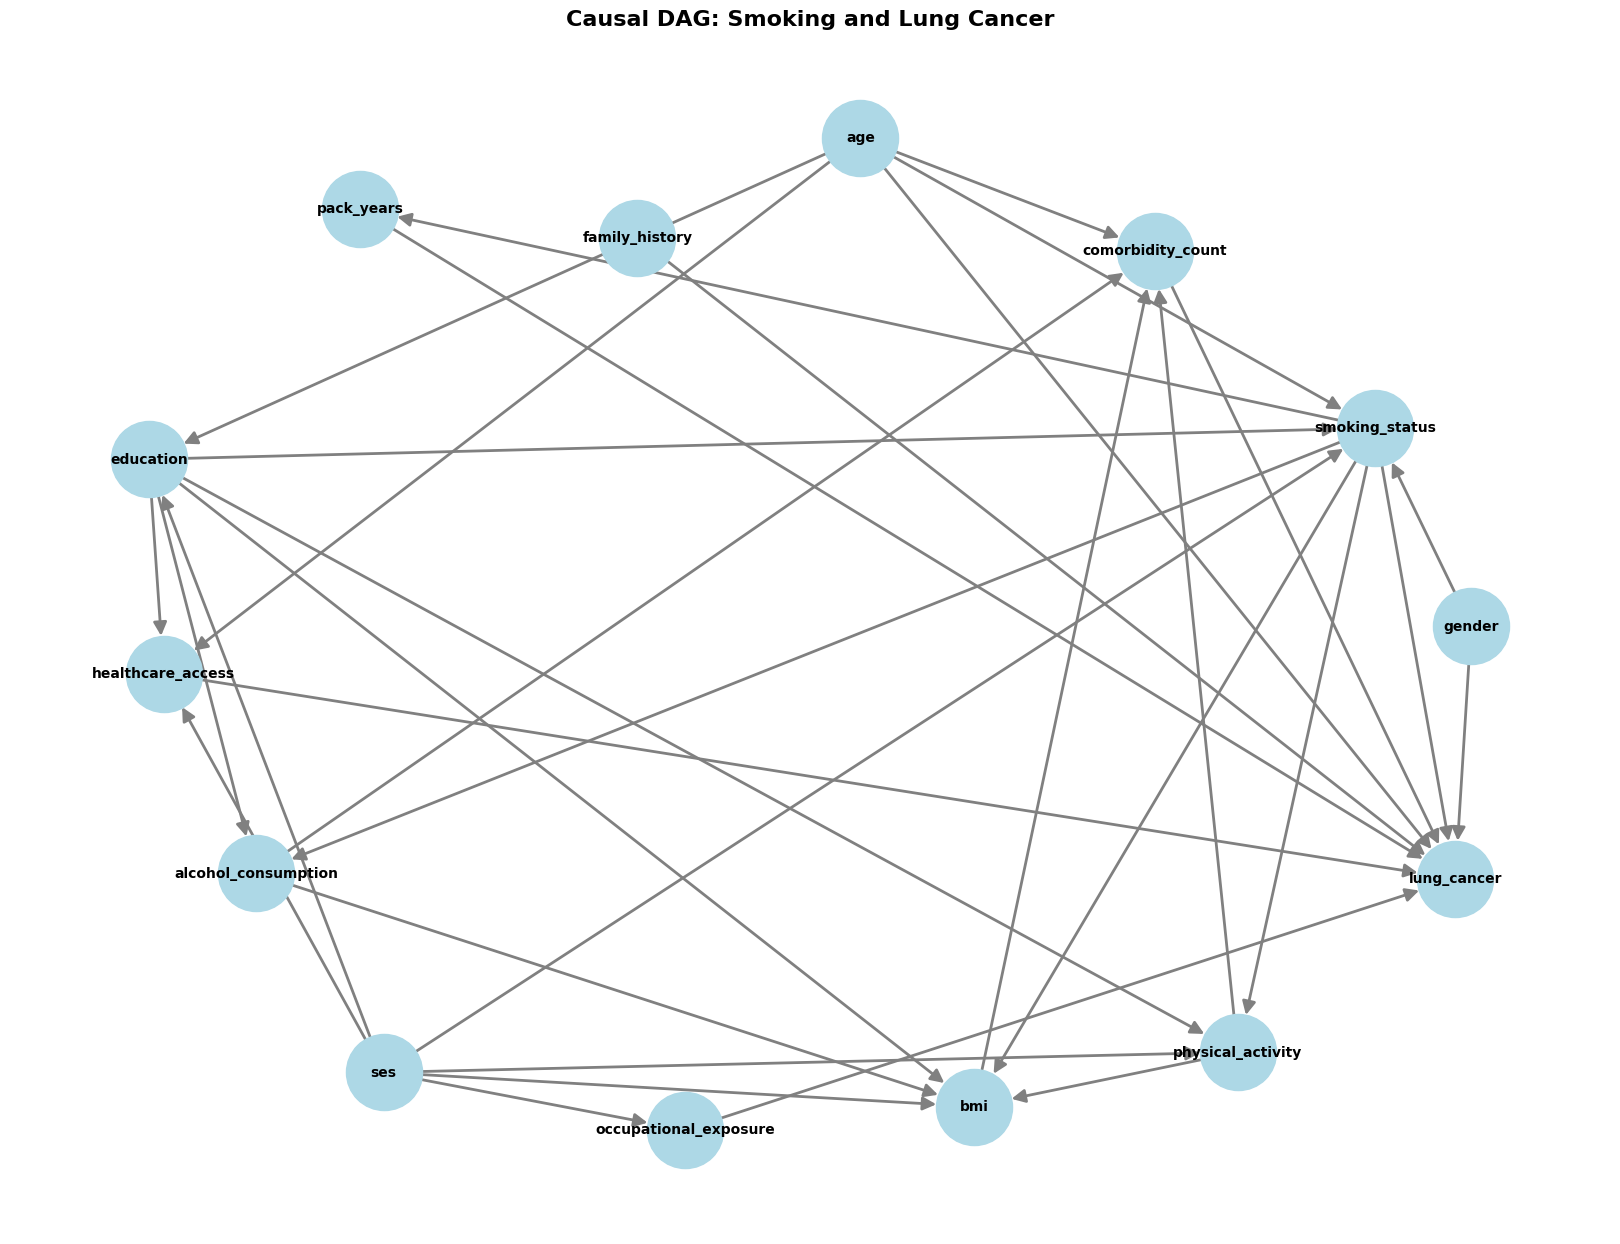


=== NODES ===
- age
- gender
- ses
- education
- smoking_status
- pack_years
- lung_cancer
- occupational_exposure
- family_history
- bmi
- physical_activity
- alcohol_consumption
- comorbidity_count
- healthcare_access

=== EDGES WITH JUSTIFICATIONS ===
age -> smoking_status: Age influences smoking initiation and cessation patterns
age -> education: Age cohorts have different educational attainment patterns
age -> lung_cancer: Age is a risk factor for cancer development
age -> comorbidity_count: Age increases comorbidity risk
age -> healthcare_access: Age affects healthcare utilization patterns
gender -> smoking_status: Gender differences in smoking prevalence
gender -> lung_cancer: Gender differences in lung cancer susceptibility
ses -> smoking_status: SES affects smoking behavior through stress, access, social norms
ses -> education: SES determines educational opportunities
ses -> occupational_exposure: Lower SES jobs may have higher exposure to carcinogens
ses -> bmi: SES influenc

In [26]:
# Visualize the DAG
plt.figure(figsize=(16, 12))
pos = nx.spring_layout(G, k=3, iterations=50, seed=42)

# Draw the graph
nx.draw(G, pos, 
        with_labels=True, 
        node_color='lightblue',
        node_size=3000,
        font_size=10,
        font_weight='bold',
        arrowsize=20,
        arrows=True,
        edge_color='gray',
        width=2)

# Add title
plt.title('Causal DAG: Smoking and Lung Cancer', fontsize=16, fontweight='bold')
plt.tight_layout()

# Save the visualization
plt.savefig('/Users/vishal/Projects/opencausol/packages/opencode/smoking_lung_cancer_dag.png', 
            dpi=300, bbox_inches='tight')
plt.show()

# Print node and edge information
print("\n=== NODES ===")
for node in G.nodes():
    print(f"- {node}")

print("\n=== EDGES WITH JUSTIFICATIONS ===")
for parent, child, data in G.edges(data=True):
    print(f"{parent} -> {child}: {data['justification']}")